# Stage 2 α-sweep — the (αₜ, αₚ, αₙ) trade-off (the X-factor)

**The project's headline experiment.** Stage 2 reranks the Stage-1 candidate pool with:

$$\text{final} = \alpha_t \cdot s_{taste} + \alpha_p \cdot s_{pantry} + \alpha_n \cdot s_{nutrition}, \qquad \alpha_t+\alpha_p+\alpha_n = 1$$

We sweep the whole weight simplex (231 points at step 0.05) and ask: **where do the best recommendations live, and what's the trade-off?**

**Setup**
- Stage 1 = **BPR** (best warm candidate generator: Recall@100 = 12.25%)
- Track = **warm**, 2000 users, leave-one-out held-out item as relevance ground truth
- Each user's **constraints are derived from their own history** — pantry = the non-staple ingredients of their 4★+ recipes; macro targets = the mean macros of those recipes

**Two families of metric**
- **Relevance** — `Recall@10`: did we surface the user's actual held-out next pick?
- **Constraint satisfaction** (dense, no ground truth) — of the top-10 we recommend, what fraction are `feasible_rate` (cookable from pantry, ≤3 missing) / `near_rate` (macros within ±20%) / `useful_rate` (both)?

Data is read from `data/processed/alpha_sweep_bpr_warm.csv`, produced by `src/eval/alpha_sweep.py` (see the reproduce cell at the bottom).

In [1]:
import os, sys
from pathlib import Path

def _root():
    p = Path(os.getcwd()).resolve()
    for c in [p, *p.parents]:
        if (c / 'pyproject.toml').exists() and (c / 'src').is_dir():
            os.chdir(c); return c
    raise RuntimeError('project root not found')
ROOT = _root()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

df = pd.read_csv('data/processed/alpha_sweep_bpr_warm.csv')
print(f'{len(df)} simplex points')
df.head()

231 simplex points


,alpha_taste,alpha_pantry,alpha_nutrition,recall@10,useful_recall@10,useful_rate@10,feasible_rate@10,near_rate@10
0,0.0,0.00,1.00,0.0125,0.0,0.01240,0.36555,0.039
1,0.0,0.05,0.95,0.0140,0.0,0.01495,0.38225,0.039
2,0.0,0.10,0.90,0.0145,0.0,0.01495,0.40020,0.039
3,0.0,0.15,0.85,0.0140,0.0,0.01495,0.42170,0.039
4,0.0,0.20,0.80,0.0125,0.0,0.01495,0.44885,0.039


## How to read a ternary plot

Each point inside the triangle is one (αₜ, αₚ, αₙ) weighting. The **corners are the pure strategies**:

- **top** = all taste (1, 0, 0)
- **bottom-left** = all pantry (0, 1, 0)
- **bottom-right** = all nutrition (0, 0, 1)

Colour = the metric value at that weighting. A ★ marks the optimum. The centre of the triangle is the balanced blend.

In [2]:
# Barycentric (αt, αp, αn) -> 2D cartesian.
# Corners: taste = top-centre, pantry = bottom-left, nutrition = bottom-right.
_A = np.array([0.5, np.sqrt(3) / 2])   # taste
_B = np.array([0.0, 0.0])              # pantry
_C = np.array([1.0, 0.0])              # nutrition

def _xy(at, ap, an):
    at, ap, an = np.asarray(at), np.asarray(ap), np.asarray(an)
    x = at * _A[0] + ap * _B[0] + an * _C[0]
    y = at * _A[1] + ap * _B[1] + an * _C[1]
    return x, y

def ternary(ax, df, col, title, cmap='viridis', pct=True):
    x, y = _xy(df['alpha_taste'], df['alpha_pantry'], df['alpha_nutrition'])
    z = df[col].to_numpy() * (100 if pct else 1)
    tri = mtri.Triangulation(x, y)
    tcf = ax.tricontourf(tri, z, levels=14, cmap=cmap)
    ax.scatter(x, y, c='white', s=2, alpha=0.25)
    # triangle outline
    ax.plot([_A[0], _B[0], _C[0], _A[0]], [_A[1], _B[1], _C[1], _A[1]], color='#2D3142', lw=1.2)
    # optimum
    bi = df[col].idxmax()
    bx, by = _xy(df.loc[bi, 'alpha_taste'], df.loc[bi, 'alpha_pantry'], df.loc[bi, 'alpha_nutrition'])
    ax.scatter([bx], [by], marker='*', s=320, color='#C75D2C', edgecolor='white', lw=1.0, zorder=5)
    # corner labels
    ax.text(_A[0], _A[1] + 0.05, 'taste\n(1,0,0)', ha='center', va='bottom', fontsize=9)
    ax.text(_B[0] - 0.03, _B[1] - 0.03, 'pantry\n(0,1,0)', ha='right', va='top', fontsize=9)
    ax.text(_C[0] + 0.03, _C[1] - 0.03, 'nutrition\n(0,0,1)', ha='left', va='top', fontsize=9)
    best = df.loc[bi]
    ax.set_title(f"{title}\nmax {z.max():.2f}{'%' if pct else ''} @ "
                 f"(t={best.alpha_taste:.2f}, p={best.alpha_pantry:.2f}, n={best.alpha_nutrition:.2f})",
                 fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal'); ax.axis('off')
    plt.colorbar(tcf, ax=ax, shrink=0.7)
    return ax

## The headline: relevance vs constraint satisfaction across the simplex

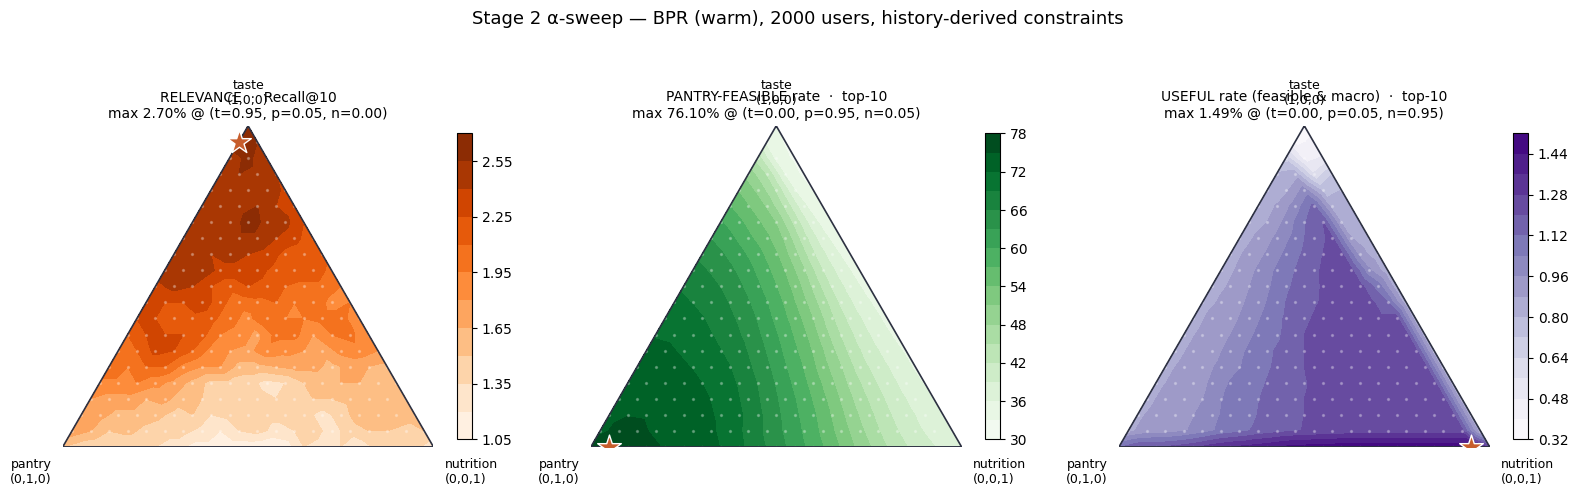

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ternary(axes[0], df, 'recall@10',        'RELEVANCE  ·  Recall@10',                cmap='Oranges')
ternary(axes[1], df, 'feasible_rate@10', 'PANTRY-FEASIBLE rate  ·  top-10',         cmap='Greens')
ternary(axes[2], df, 'useful_rate@10',   'USEFUL rate (feasible & macro)  ·  top-10', cmap='Purples')
fig.suptitle('Stage 2 α-sweep — BPR (warm), 2000 users, history-derived constraints', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('data/processed/alpha_sweep_ternary.png', dpi=150, bbox_inches='tight')
plt.show()

## Reading the three panels

- **Relevance (Recall@10)** peaks hard at the **taste corner** — to surface the user's actual next pick, weight Stage-1 taste. Adding pantry/nutrition weight monotonically trades relevance away.
- **Pantry-feasible rate** is the mirror image — it peaks at the **pantry corner** (≈76% of the top-10 cookable from the user's pantry, vs ≈33% at the taste corner). This is the strongest, cleanest α response.
- **Useful rate** (feasible AND macro-near) leans toward the **nutrition/pantry edge**, but stays low in absolute terms — capped by the macro constraint (see caveat below).

**No corner wins everything.** Relevance and constraint-satisfaction are in tension; the optimum depends on what you weight — which is precisely the trade-off the project set out to characterize.

In [4]:
def at(t, p, n):
    r = df[(df.alpha_taste == t) & (df.alpha_pantry == p) & (df.alpha_nutrition == n)]
    return r.iloc[0] if len(r) else None

rows = []
for label, w in [('taste (1,0,0)', (1.0, 0.0, 0.0)),
                 ('pantry (0,1,0)', (0.0, 1.0, 0.0)),
                 ('nutrition (0,0,1)', (0.0, 0.0, 1.0)),
                 ('balanced (.4,.3,.3)', (0.4, 0.3, 0.3))]:
    r = at(*w)
    if r is not None:
        rows.append({
            'point': label,
            'recall@10 %': round(r['recall@10'] * 100, 3),
            'feasible_rate@10 %': round(r['feasible_rate@10'] * 100, 1),
            'near_rate@10 %': round(r['near_rate@10'] * 100, 1),
            'useful_rate@10 %': round(r['useful_rate@10'] * 100, 2),
        })
pd.DataFrame(rows).set_index('point')

,recall@10 %,feasible_rate@10 %,near_rate@10 %,useful_rate@10 %
point,,,,
"taste (1,0,0)",2.70,33.1,2.6,0.38
"pantry (0,1,0)",1.50,75.9,2.5,1.11
"nutrition (0,0,1)",1.25,36.6,3.9,1.24
"balanced (.4,.3,.3)",1.90,59.1,3.7,1.18


## Caveats + notes

- **The macro constraint is binding.** `near_rate` (all 5 macros within ±20%) stays at 2.5–3.9% across the whole simplex — it's simply hard to hit five macro targets at once. So the combined `useful_rate` is capped low. For the deck, `feasible_rate` (33%→76%) is the cleaner demonstration of the α response; `useful_rate` shows the same direction but smaller in magnitude.
- **Strict Useful Recall is degenerate here.** Requiring the *single* held-out item to be both in top-10 AND useful qualifies only ~21/2000 users → ~0.05% (noise). That's why we report the **dense** top-10 rates instead. (The `useful_recall@10` column is in the CSV for completeness but isn't the headline.)
- **Relevance ceiling is BPR's.** Only ~12% of held-out items are in BPR's top-100 pool at all (warm Recall@100), so Recall@10 tops out near 2.7%. Stage 2 reorders within that pool; it can't recall an item BPR never surfaced.

## Reproduce

The CSV is generated by `src/eval/alpha_sweep.py`:

```python
from src.data.loader import load_train_interactions, load_recipes, time_based_split
from src.models.bpr import BPRRecommender
from src.eval.alpha_sweep import derive_user_constraints, precompute_user_cases, sweep
import random, numpy as np

full = load_train_interactions()
train_part, test_part = time_based_split(full, holdout_per_user=1)
recipes = load_recipes(); recipes['id'] = recipes['id'].astype(np.int64)
recipes = recipes.set_index('id'); recipes.index.name = 'recipe_id'
holdout = test_part.groupby('user_id')['recipe_id'].first().to_dict()
users = random.Random(42).sample(list(holdout), 2000)
hmap = {int(u): int(holdout[u]) for u in users}

bpr = BPRRecommender(seed=42).fit(train_part)
cons = derive_user_constraints(train_part, recipes, users)
cases = precompute_user_cases(bpr, hmap, recipes, cons, k_pool=100)
sweep(cases, k=10, step=0.05).to_csv('data/processed/alpha_sweep_bpr_warm.csv', index=False)
```

**Next:** swap BPR → SBERT for a cold-track sweep; or run the same sweep on the persona profiles for the live demo.